<a href="https://colab.research.google.com/github/camilogomezos/ICTC_TimeSeries_ARMA/blob/main/ARIMA_2_1_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# Trabajar con rutas relativas en python
from pathlib import Path

# Módulos de numpy, pandas, matplotlib y scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import jarque_bera, probplot
import seaborn as sns
import scipy.stats as stats

# Módulos de statsmodels
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
# Leemos el archivo directamente desde GitHub
url = 'https://raw.githubusercontent.com/camilogomezos/ICTC_TimeSeries_ARMA/refs/heads/main/ICTC_Indices_abr2026.csv'
df = pd.read_csv(url, decimal=',')

if df['ICTC'].dtype == 'O':
    df['ICTC'] = df['ICTC'].str.replace('"', '').str.replace(',', '.').astype(float)

df['Fecha'] = pd.date_range(start='2016-01-01', periods=len(df), freq='MS')
df.set_index('Fecha', inplace=True)
serie = df['ICTC']
print(serie)

Fecha
2016-01-01    101.41
2016-02-01    101.40
2016-03-01    100.58
2016-04-01    100.22
2016-05-01    100.75
               ...  
2025-12-01    154.95
2026-01-01    160.40
2026-02-01    161.84
2026-03-01    162.11
2026-04-01    162.91
Name: ICTC, Length: 124, dtype: float64


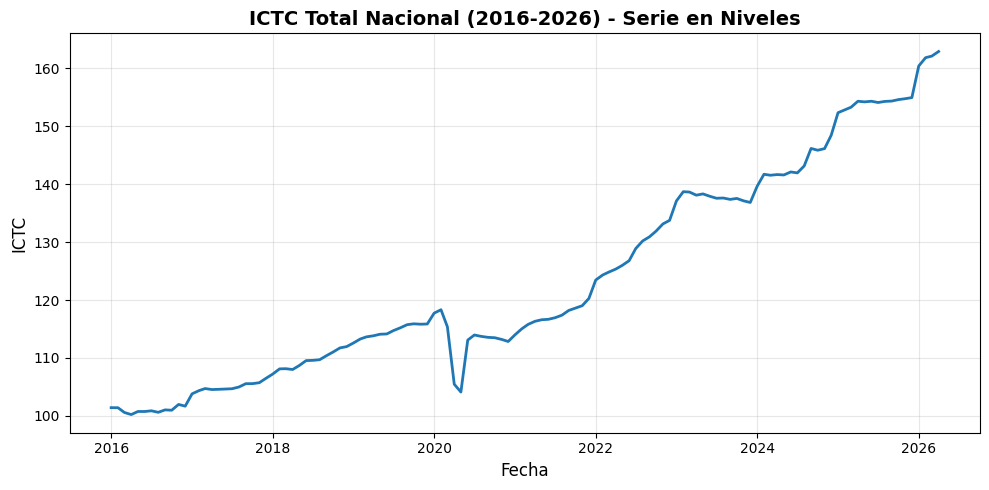

In [ ]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=serie, color='#1f77b4', linewidth=2)
plt.title('ICTC Total Nacional (2016-2026) - Serie en Niveles', fontsize=14, fontweight='bold')
plt.ylabel('ICTC', fontsize=12)
plt.xlabel('Fecha', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('grafica_nivel.png')
plt.show()

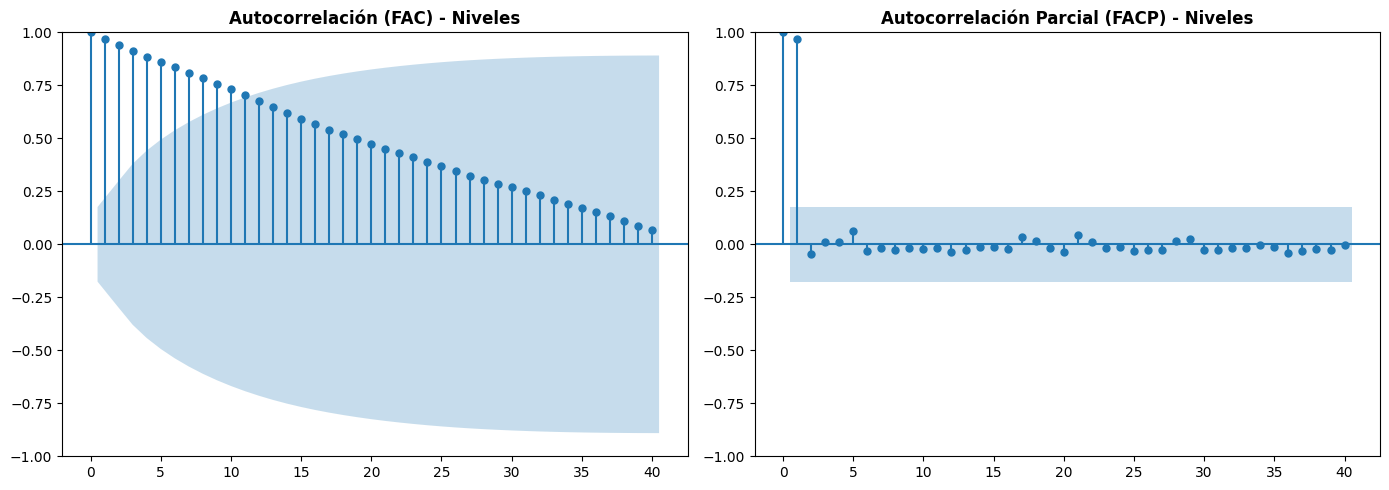

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(serie, ax=axes[0], lags=40, color='#1f77b4', alpha=0.05)
axes[0].set_title('Autocorrelación (FAC) - Niveles', fontweight='bold')
plot_pacf(serie, ax=axes[1], lags=40, color='#1f77b4', alpha=0.05)
axes[1].set_title('Autocorrelación Parcial (FACP) - Niveles', fontweight='bold')
plt.tight_layout()
plt.savefig('grafica_fac_facp.png')
plt.show()

In [ ]:
# %% Tests de Raíz Unitaria

# Test de Augmented Dickey Fuller (ADF)
adf_result = adfuller(serie) # Test de Dickey Fuller sin intercepto y tendencia determínistica

# Nota: En el test de ADF si no rechazo la H0 la serie no es estacionaria
#       y si rechazo la H0 la serie es estacionaria.

print("=== Test ADF ===")
print("Estadístico ADF:", adf_result[0])
print("p-valor:", adf_result[1])
print("Rezagos usados:", adf_result[2])
print("Observaciones:", adf_result[3])
print("Valores críticos:")
for nivel, valor in adf_result[4].items():
    print(f"{nivel}: {valor}")

if adf_result[1] < 0.05:
    print("ADF: Rechazamos H0. Según el test, la serie es estacionaria.")
else:
    print("ADF: No rechazamos H0. Según el test, la serie no es estacionaria.")

=== Test ADF ===
Estadístico ADF: 1.6541360189646748
p-valor: 0.9980112332710951
Rezagos usados: 2
Observaciones: 121
Valores críticos:
1%: -3.485585145896754
5%: -2.885738566292665
10%: -2.5796759080663887
ADF: No rechazamos H0. Según el test, la serie no es estacionaria.


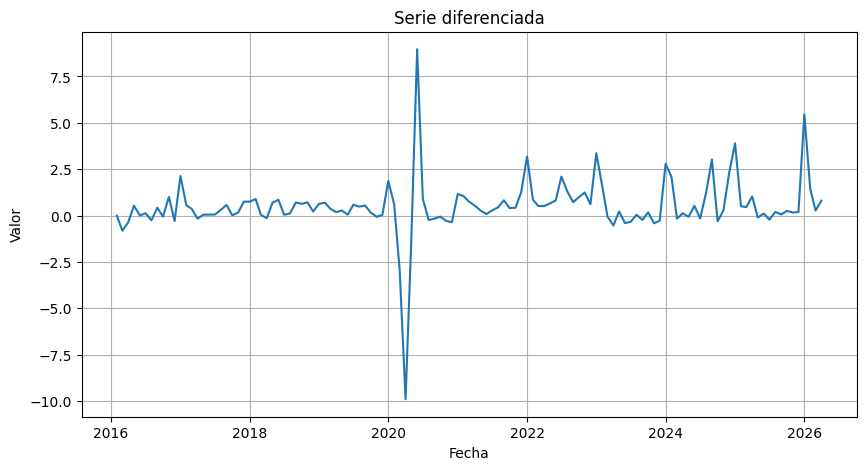

In [ ]:
# %% Serie diferenciada
serie_diff = serie.diff().dropna()

# Gráfica de la serie de tiempo de la "diferencia exportaciones tradicionales"
plt.figure(figsize=(10, 5))
plt.plot(serie_diff)
plt.title("Serie diferenciada")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.grid(True)
plt.show()

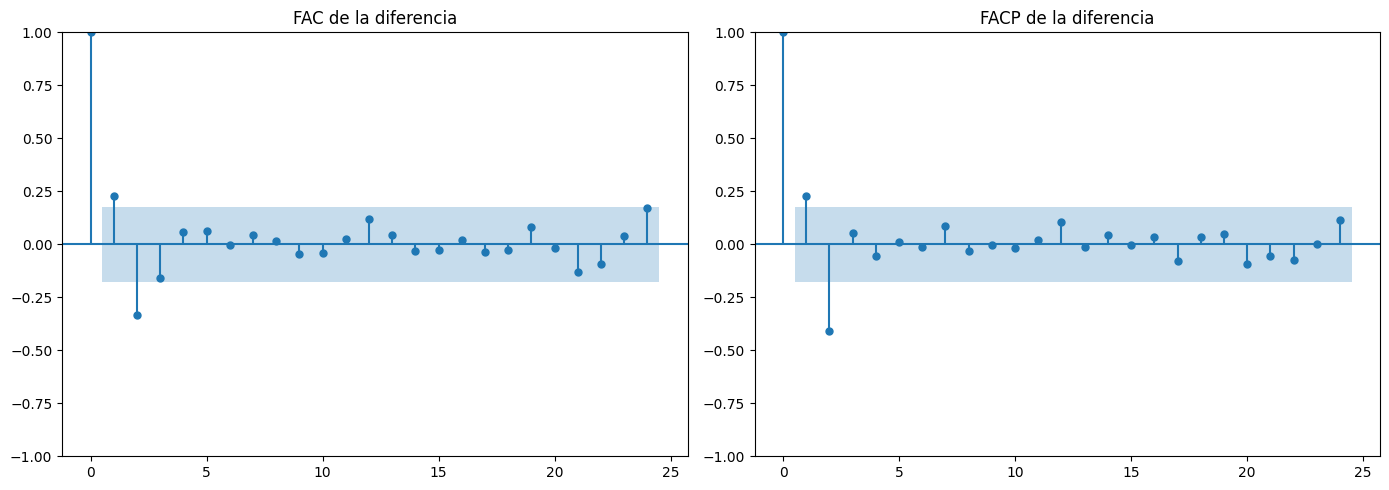

In [ ]:
# %% FAC y FACP de la diferencia

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(
    serie_diff,
    lags=24,
    alpha=0.05,
    bartlett_confint=False,
    ax=axes[0]
)

axes[0].set_title("FAC de la diferencia")

plot_pacf(
    serie_diff,
    lags=24,
    alpha=0.05,
    ax=axes[1]
)

axes[1].set_title("FACP de la diferencia")

plt.tight_layout()
plt.show()

In [ ]:
# %% Tests de Raíz Unitaria

# Test de Augmented Dickey Fuller (ADF)
adf_result = adfuller(serie_diff) # Test de Dickey Fuller sin intercepto y tendencia determínistica

# Nota: En el test de ADF si no rechazo la H0 la serie no es estacionaria
#       y si rechazo la H0 la serie es estacionaria.

print("=== Test ADF ===")
print("Estadístico ADF:", adf_result[0])
print("p-valor:", adf_result[1])
print("Rezagos usados:", adf_result[2])
print("Observaciones:", adf_result[3])
print("Valores críticos:")
for nivel, valor in adf_result[4].items():
    print(f"{nivel}: {valor}")

if adf_result[1] < 0.05:
    print("ADF: Rechazamos H0. Según el test, la serie es estacionaria.")
else:
    print("ADF: No rechazamos H0. Según el test, la serie no es estacionaria.")

=== Test ADF ===
Estadístico ADF: -10.453296593632542
p-valor: 1.4197572319551024e-18
Rezagos usados: 1
Observaciones: 121
Valores críticos:
1%: -3.485585145896754
5%: -2.885738566292665
10%: -2.5796759080663887
ADF: Rechazamos H0. Según el test, la serie es estacionaria.


In [ ]:
resultados = []

for p in range(3):
    for q in range(3):
        try:
            # order=(p, d, q) -> d=1 porque sabemos que requiere una diferencia
            modelo = ARIMA(serie_diff, order=(p, 0, q))
            ajuste = modelo.fit()
            resultados.append({
                'Modelo': f'ARIMA({p}, 0, {q})',
                'AIC': ajuste.aic,
                'BIC': ajuste.bic
            })
        except:
            continue

# Ordenar los resultados para encontrar el modelo más parsimonioso
df_resultados = pd.DataFrame(resultados).sort_values(by='BIC').reset_index(drop=True)
print(df_resultados)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

           Modelo         AIC         BIC
0  ARIMA(2, 0, 0)  437.595983  448.844721
1  ARIMA(0, 0, 2)  440.747180  451.995917
2  ARIMA(2, 0, 1)  439.174293  453.235215
3  ARIMA(1, 0, 2)  440.553871  454.614793
4  ARIMA(0, 0, 1)  446.362574  454.799128
5  ARIMA(1, 0, 1)  444.986719  456.235457
6  ARIMA(2, 0, 2)  440.867267  457.740374
7  ARIMA(1, 0, 0)  457.682397  466.118950
8  ARIMA(0, 0, 0)  462.193266  467.817635


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Paso 2. Estimación

In [ ]:
modelo= SARIMAX(
    serie_diff,
    order=(2, 0, 0),
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Objeto tipo "SARIMAX" del paquete statmodels
type(modelo)

#  Acá es donde se realiza la estimación del modelo MA(1)
estimacion = modelo.fit(disp=False)

# Nota: El método de estimación es máxima verosimilitud
#       sobre la representación del modelo en un espacio de estados

# Objeto tipo "SARIMAXResultsWrapper"
type(estimacion)

# Se imprimen los resultados principales de la estimación
# E.g. Coeficientes y significancia de los coeficientes
print(estimacion.summary())


                               SARIMAX Results                                
Dep. Variable:                   ICTC   No. Observations:                  123
Model:               SARIMAX(2, 0, 0)   Log Likelihood                -219.553
Date:                Sat, 30 May 2026   AIC                            445.105
Time:                        02:32:01   BIC                            453.493
Sample:                    02-01-2016   HQIC                           448.512
                         - 04-01-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3983      0.058      6.860      0.000       0.285       0.512
ar.L2         -0.3284      0.039     -8.517      0.000      -0.404      -0.253
sigma2         2.2058      0.137     16.088      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Paso 3. Validación de supuestos

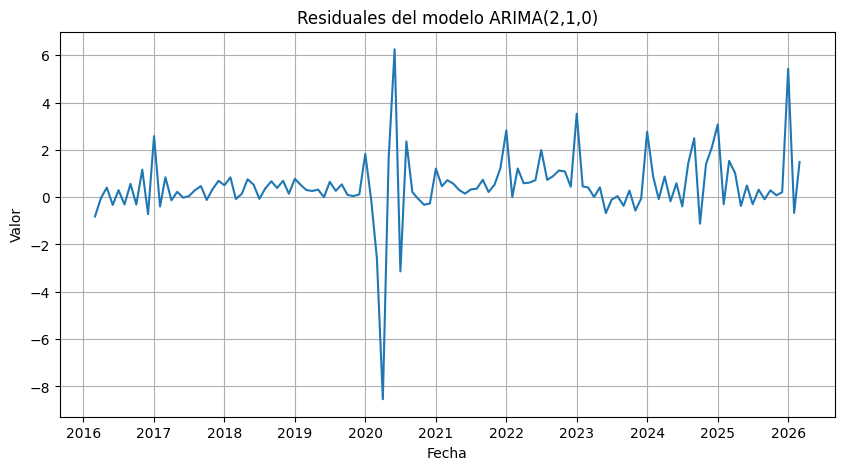

count    123.000000
mean       0.464782
std        1.405485
min       -8.541097
25%       -0.046750
50%        0.343229
75%        0.765590
max        6.252899
dtype: float64


In [ ]:
# Residuales del modelo
residuales = estimacion.resid.dropna()

# Los residuales son un objeto tipo Pandas.Series
type(residuales)

# Gráfica de los residuales (deberían comportarse como ruido blanco)
plt.figure(figsize=(10, 5))
plt.plot(residuales.iloc[1:-1])
plt.title("Residuales del modelo ARIMA(2,1,0)")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.grid(True)
plt.show()

# Descripción de los residuales
print(residuales.describe())


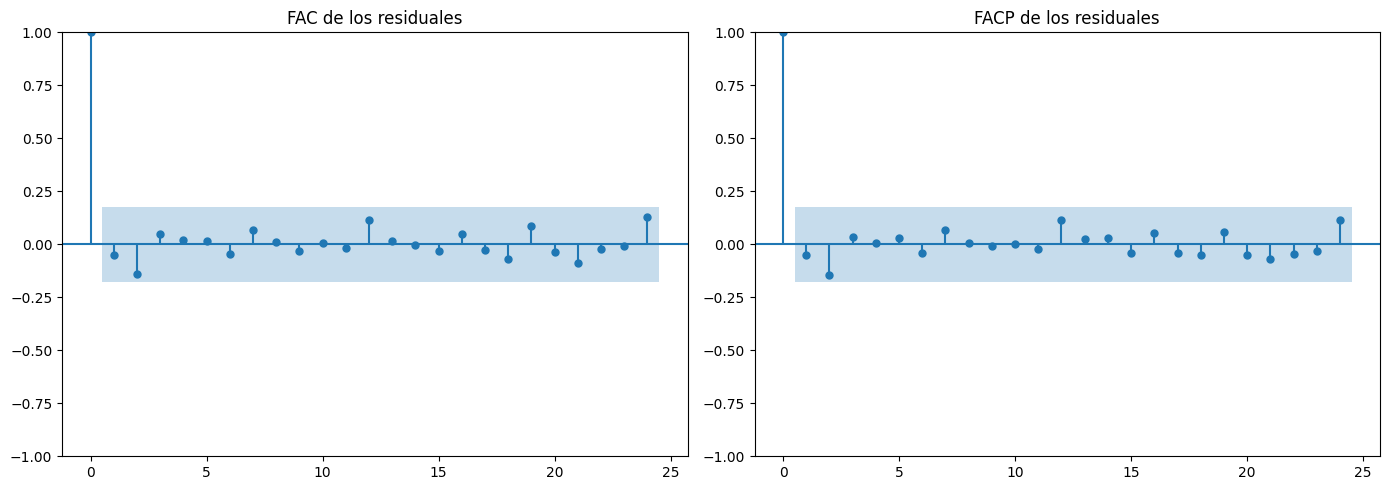

In [ ]:
# %% FAC y FACP de los residuales

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(
    residuales,
    lags=24,
    alpha=0.05,
    bartlett_confint=False,
    ax=axes[0]
)

axes[0].set_title("FAC de los residuales")

plot_pacf(
    residuales,
    lags=24,
    alpha=0.05,
    ax=axes[1]
)

axes[1].set_title("FACP de los residuales")

plt.tight_layout()
plt.show()


In [ ]:
# %% Prueba Ljung-Box

ljung_box = acorr_ljungbox(
    residuales,
    lags=[6, 12, 18, 24],
    return_df=True
)

print("Prueba Ljung-Box")
print(ljung_box)

# H0: no hay autocorrelación en los residuos.
# Si p-value > 0.05, no se rechaza H0.


Prueba Ljung-Box
      lb_stat  lb_pvalue
6    3.448400   0.750822
12   6.019158   0.915113
18   7.404523   0.986248
24  12.651034   0.971530


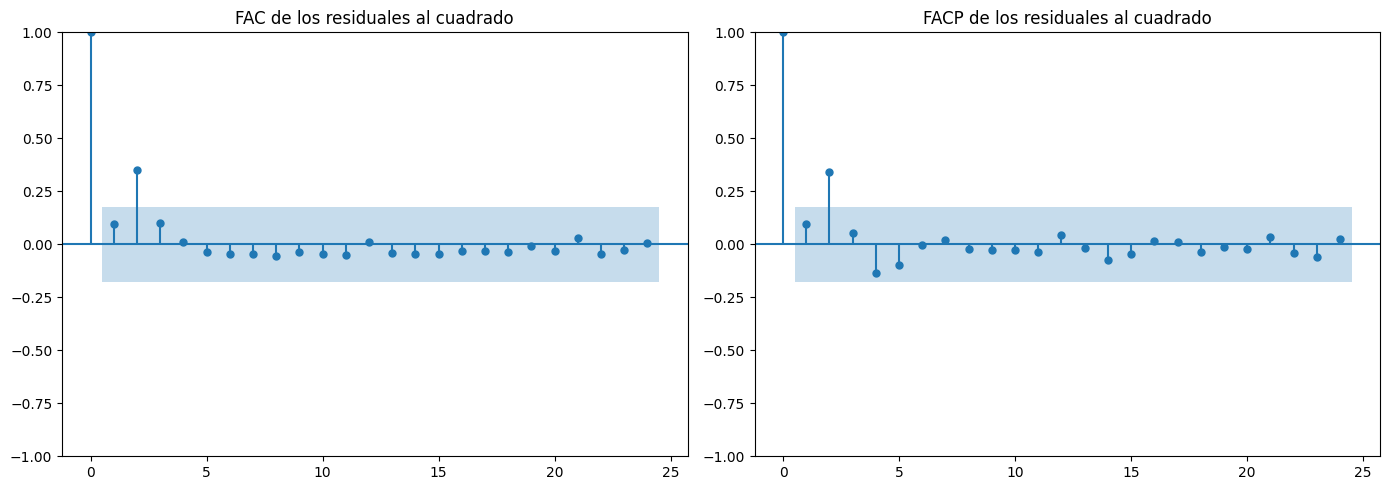

In [ ]:
# %% FAC y FACP de los residuales al cuadrado

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(
    residuales**2,
    lags=24,
    alpha=0.05,
    bartlett_confint=False,
    ax=axes[0]
)

axes[0].set_title("FAC de los residuales al cuadrado")

plot_pacf(
    residuales**2,
    lags=24,
    alpha=0.05,
    ax=axes[1]
)

axes[1].set_title("FACP de los residuales al cuadrado")

plt.tight_layout()
plt.show()


In [ ]:
# %% Prueba ARCH de heterocedasticidad

arch_test = het_arch(residuales, nlags=12)

print("Prueba ARCH")
print("LM statistic:", arch_test[0])
print("LM p-value:", arch_test[1])

# H0: no hay efectos ARCH.
# Si p-value > 0.05, no se rechaza H0.

Prueba ARCH
LM statistic: 17.76517691785416
LM p-value: 0.1230088104864083


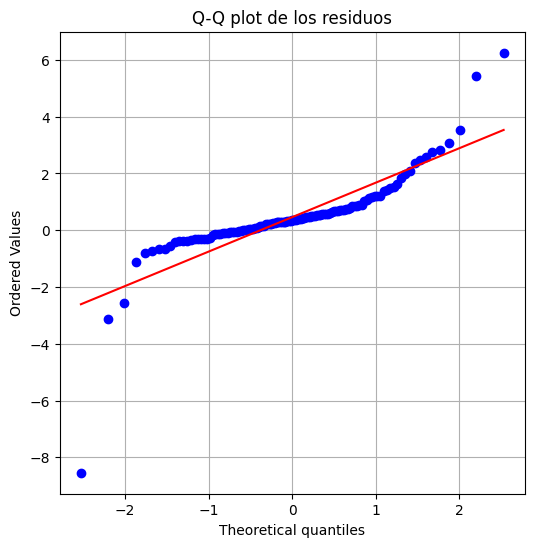

In [ ]:
# %% Q-Q plot de los residuos

plt.figure(figsize=(6, 6))
probplot(residuales.iloc[1:-1], dist="norm", plot=plt)
plt.title("Q-Q plot de los residuos")
plt.grid(True)
plt.show()

In [ ]:
# %% Prueba de normalidad Jarque-Bera

jb_test = jarque_bera(residuales.iloc[1:-1])

print("Prueba Jarque-Bera")
print("Jarque-Bera statistic:", jb_test.statistic)
print("Jarque-Bera p-value:", jb_test.pvalue)

# H0: los residuos no siguen una distribución normal.
# Si p-value < 0.05, se rechaza H0.

Prueba Jarque-Bera
Jarque-Bera statistic: 1244.0848191674452
Jarque-Bera p-value: 7.086209828215569e-271


4. Pronostico

            pronostico  limite_inferior  limite_superior
2026-05-01  163.139997       160.229069       166.050926
2026-06-01  162.968862       156.924553       169.013171
2026-07-01  162.825150       153.608731       172.041568
2026-08-01  162.824111       150.383407       175.264814
2026-09-01  162.870898       147.205197       178.536599
2026-10-01  162.889877       143.995075       181.784679
2026-11-01  162.882070       140.756992       185.007147
2026-12-01  162.872727       137.517320       188.228134
2027-01-01  162.871569       134.285631       191.457507
2027-02-01  162.874176       131.057697       194.690656
2027-03-01  162.875595       127.828563       197.922628
2027-04-01  162.875304       124.597713       201.152895


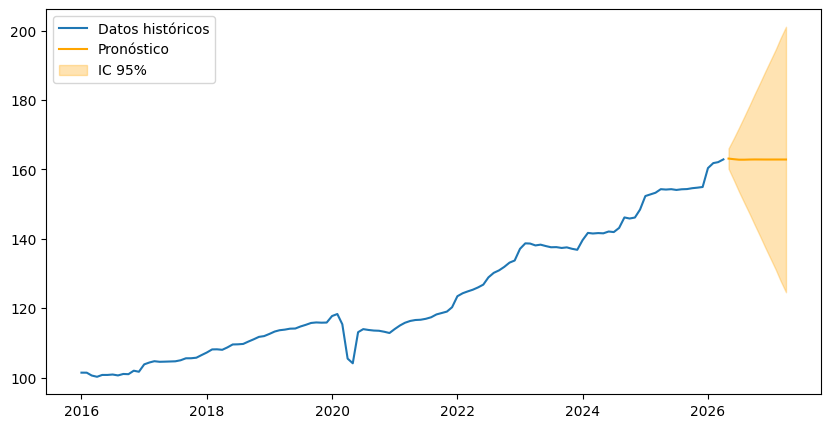

In [ ]:
pronostico_diff = estimacion.get_forecast(steps=12)

pronostico_puntual = pronostico_diff.predicted_mean

intervalos = pronostico_diff.conf_int()


ultimo_valor = serie.iloc[-1]

pronostico_nivel = ultimo_valor + pronostico_puntual.cumsum()

limite_inferior = (
    ultimo_valor +
    intervalos.iloc[:, 0].cumsum()
)

limite_superior = (
    ultimo_valor +
    intervalos.iloc[:, 1].cumsum()
)

tabla_pronostico = pd.DataFrame({
    "pronostico": pronostico_nivel,
    "limite_inferior": limite_inferior,
    "limite_superior": limite_superior
})


print(tabla_pronostico)


plt.figure(figsize=(10,5))

plt.plot(
    serie,
    label="Datos históricos"
)

plt.plot(
    pronostico_nivel,
    label="Pronóstico",
    color="orange"
)

plt.fill_between(
    pronostico_nivel.index,
    limite_inferior,
    limite_superior,
    color="orange",
    alpha=0.3,
    label="IC 95%"
)

plt.legend()
plt.show()